In [1]:
import pandas as pd

# Caricamento dei file CSV
events = pd.read_csv('events.csv')
users = pd.read_csv('users.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
inventory = pd.read_csv('inventory_items.csv')
distribution_centers = pd.read_csv('distribution_centers.csv')

# Opzionali: sample o dati arricchiti
events_sampled = pd.read_csv('events_sampled.csv')
users_enriched = pd.read_csv('users_enriched.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'events.csv'

Numero totale di eventi: 2421714

Tipi di evento più frequenti:
event_type
product       842972
department    593254
cart          592736
purchase      180852
cancel        124554
home           87346
Name: count, dtype: int64

Traffico per sorgente:
traffic_source
Email       1086611
Adwords      726699
YouTube      244276
Facebook     242348
Organic      121780
Name: count, dtype: int64

Top 10 pagine più visitate:
                                            page_url  visits
0                                              /cart  592736
1                                          /purchase  180852
2                                            /cancel  124554
3                                              /home   87346
4  /department/women/category/maternity/brand/mot...    3293
5  /department/women/category/blazers&jackets/bra...    3031
6      /department/men/category/jeans/brand/wrangler    2539
7  /department/women/category/dresses/brand/allegrak    2261
8     /department/men/category

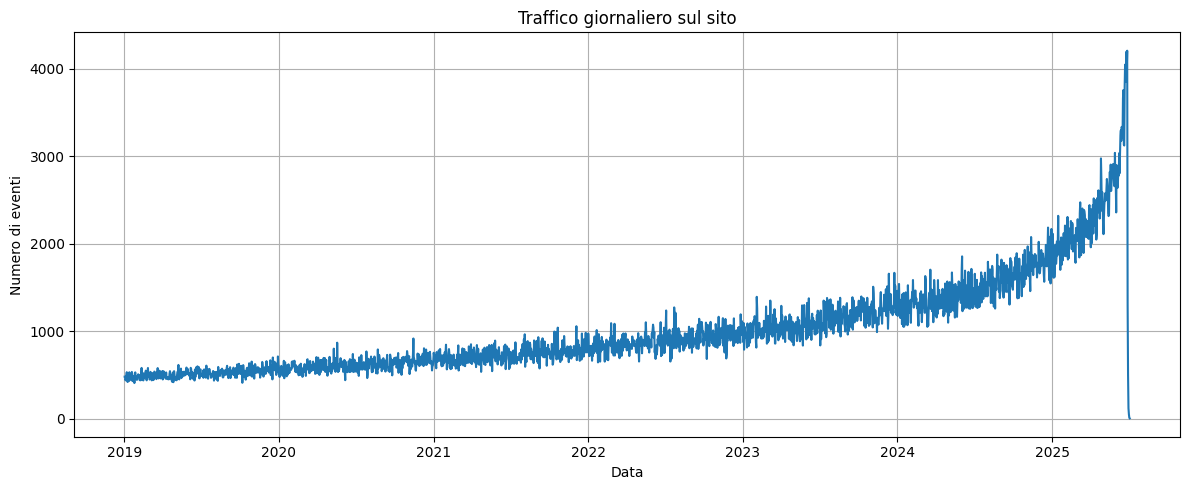

In [15]:
import matplotlib.pyplot as plt

# 🔢 1. Numero totale di eventi registrati (click, visualizzazioni, ecc.)
total_events = len(events)
print(f"Numero totale di eventi: {total_events}")

# 📊 2. Tipi di evento più frequenti (es: 'page_view', 'add_to_cart', ecc.)
event_type_counts = events['event_type'].value_counts()
print("\nTipi di evento più frequenti:")
print(event_type_counts)

# 🌍 3. Traffico per sorgente (es: 'direct', 'email', 'ads', ecc.)
traffic_by_source = events['traffic_source'].value_counts()
print("\nTraffico per sorgente:")
print(traffic_by_source)

# 📄 4. Pagine (uri) più visitate (top 10)
top_pages = events['uri'].value_counts().head(10).reset_index()
top_pages.columns = ['page_url', 'visits']
print("\nTop 10 pagine più visitate:")
print(top_pages)

# 📅 5. Evoluzione temporale del traffico (eventi giornalieri)
events['created_at'] = pd.to_datetime(events['created_at'])  # assicurati che sia in formato datetime
daily_traffic = events.groupby(events['created_at'].dt.date).size()

# 📈 Plot del traffico giornaliero
plt.figure(figsize=(12, 5))
daily_traffic.plot()
plt.title("Traffico giornaliero sul sito")
plt.xlabel("Data")
plt.ylabel("Numero di eventi")
plt.grid(True)
plt.tight_layout()
plt.show()


Distribuzione numero eventi per utente:

count    80114.000000
mean        16.190853
std         16.823150
min          5.000000
25%          5.000000
50%         10.000000
75%         19.000000
max        161.000000
Name: count, dtype: float64

Numero di utenti fedeli (>=5 eventi): 80114

Sorgenti di traffico degli utenti fedeli:
traffic_source
Email       581399
Adwords     389555
YouTube     130823
Facebook    129239
Organic      66098
Name: count, dtype: int64


/tmp/ipython-input-16-630848584.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loyal_traffic_sources.index, y=loyal_traffic_sources.values, palette="viridis")


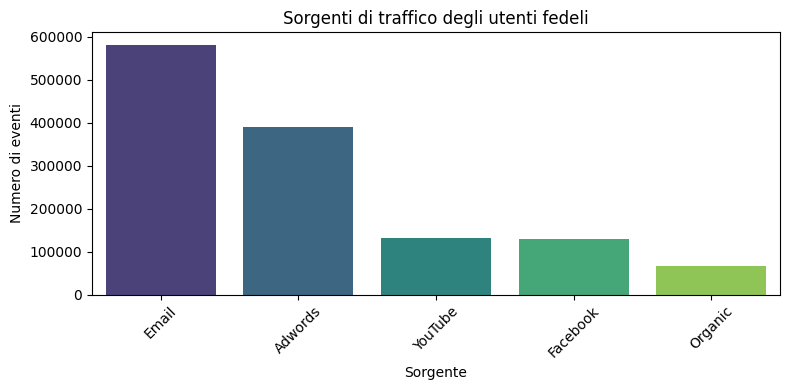

In [16]:
# 👤 1. Numero di eventi per utente
user_event_counts = events['user_id'].value_counts()
print("Distribuzione numero eventi per utente:\n")
print(user_event_counts.describe())

# 🏅 2. Utenti fedeli: almeno 5 eventi (soglia modificabile)
loyal_users = user_event_counts[user_event_counts >= 5].index
print(f"\nNumero di utenti fedeli (>=5 eventi): {len(loyal_users)}")

# 🎯 3. Filtra gli eventi solo per utenti fedeli
loyal_events = events[events['user_id'].isin(loyal_users)]

# 📊 4. Sorgenti di traffico preferite dagli utenti fedeli
loyal_traffic_sources = loyal_events['traffic_source'].value_counts()
print("\nSorgenti di traffico degli utenti fedeli:")
print(loyal_traffic_sources)

# 📈 5. Visualizza la distribuzione dei canali in un grafico a barre
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.barplot(x=loyal_traffic_sources.index, y=loyal_traffic_sources.values, palette="viridis")
plt.title("Sorgenti di traffico degli utenti fedeli")
plt.xlabel("Sorgente")
plt.ylabel("Numero di eventi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-19-2873481175.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_sales', y='name', data=top_products, palette='crest')


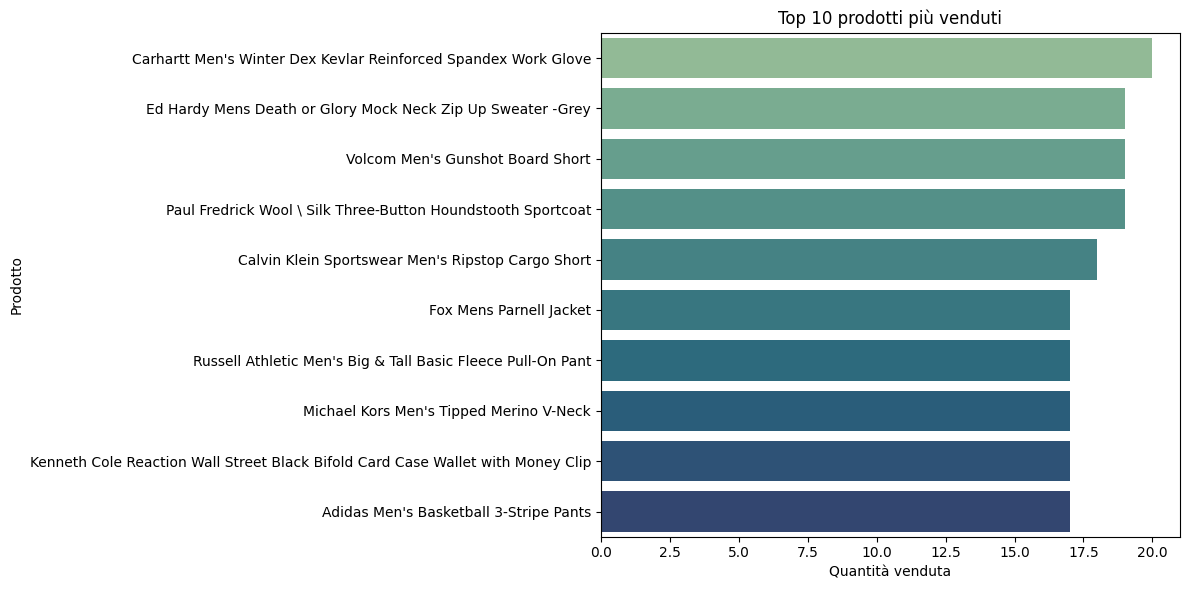

In [19]:
# 1. Conta quante volte ogni prodotto è stato venduto
product_sales = order_items.groupby('product_id').size().reset_index(name='total_sales')

# 2. Unisci con i dettagli dei prodotti
product_details = products[['id', 'name', 'category', 'brand']]
product_sales = product_sales.merge(product_details, left_on='product_id', right_on='id', how='left')

# 3. Ordina per vendite decrescenti e prendi i top 10
top_products = product_sales.sort_values(by='total_sales', ascending=False).head(10)

# 4. Visualizza
plt.figure(figsize=(12, 6))
sns.barplot(x='total_sales', y='name', data=top_products, palette='crest')
plt.title('Top 10 prodotti più venduti')
plt.xlabel('Quantità venduta')
plt.ylabel('Prodotto')
plt.tight_layout()
plt.show()



/tmp/ipython-input-22-3271479889.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='user_count', y='state', data=top_states, palette='crest')


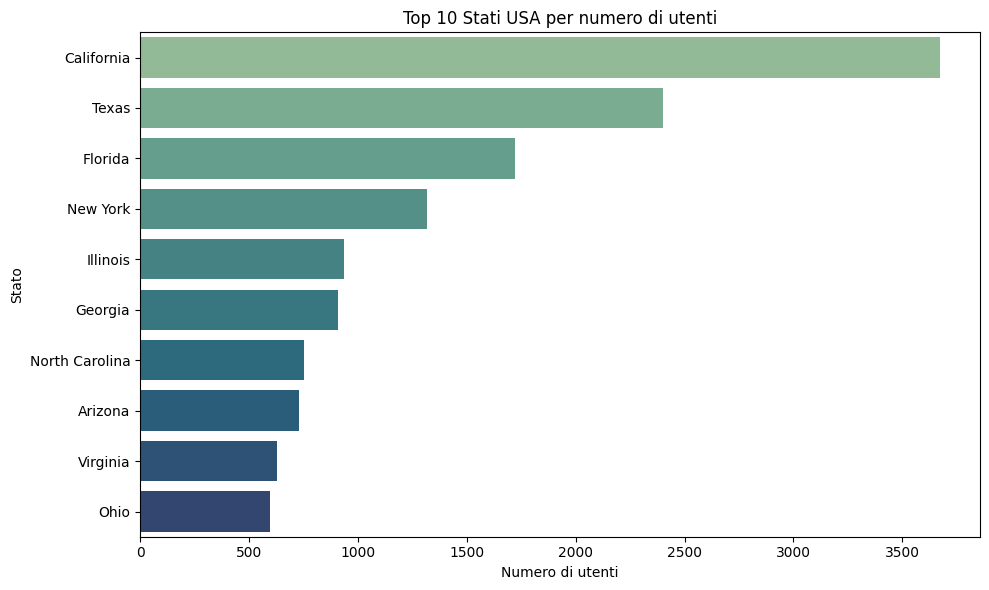

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filtro per utenti negli Stati Uniti (adatta in base ai valori reali se serve)
usa_users = users[users['country'].str.contains('USA|United States', case=False, na=False)]

# Raggruppa per stato e conta gli utenti
state_distribution = usa_users.groupby('state').size().reset_index(name='user_count')

# Ordina per numero di utenti e prendi i primi 10
top_states = state_distribution.sort_values(by='user_count', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='user_count', y='state', data=top_states, palette='crest')
plt.title('Top 10 Stati USA per numero di utenti')
plt.xlabel('Numero di utenti')
plt.ylabel('Stato')
plt.tight_layout()
plt.show()


/tmp/ipython-input-24-1484607209.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='user_count', y='country', data=top_countries, palette='crest')


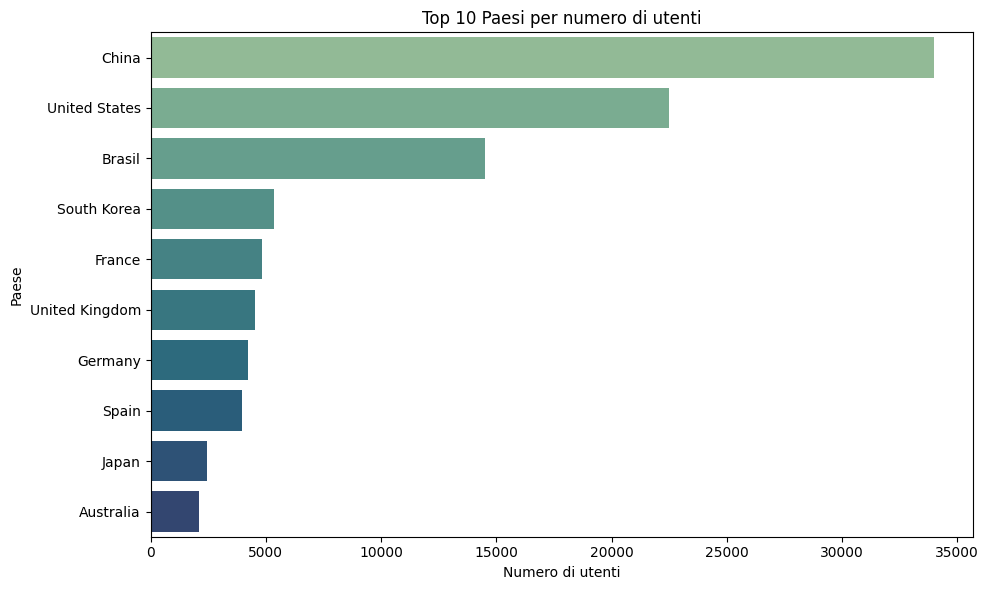

In [24]:
# Raggruppa per paese e conta il numero di utenti
country_distribution = users[users['country'].notna()] \
    .groupby('country').size().reset_index(name='user_count')

# Ordina per numero di utenti e seleziona i top 10
top_countries = country_distribution.sort_values(by='user_count', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='user_count', y='country', data=top_countries, palette='crest')
plt.title('Top 10 Paesi per numero di utenti')
plt.xlabel('Numero di utenti')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()


In [30]:
orders['created_at'] = pd.to_datetime(orders['created_at'], errors='coerce')


In [34]:
import pandas as pd

# Assumendo che i due DataFrame si chiamino così:
# orders         -> contiene: order_id, created_at
# order_items    -> contiene: order_id, sale_price, created_at

# Conversione della colonna created_at in datetime nel DataFrame order_items
order_items['created_at'] = pd.to_datetime(order_items['created_at'], errors='coerce')

# Calcolo delle vendite giornaliere
daily_sales = order_items.groupby(order_items['created_at'].dt.date)['sale_price'].sum().reset_index()

# Rinomina le colonne
daily_sales.columns = ['date', 'total_sales']

# Visualizza le prime righe
print(daily_sales.head())



         date  total_sales
0  2019-01-04        25.00
1  2019-01-05        91.50
2  2019-01-08        16.00
3  2019-01-12        13.11
4  2019-01-15        30.00


In [37]:
import pandas as pd

# Parsing robusto con il parser flessibile
inventory['created_at'] = inventory['created_at'].apply(lambda x: pd.to_datetime(x, utc=True))



In [38]:
latest_inventory = (
    inventory.sort_values('created_at')
    .drop_duplicates(subset='product_id', keep='last')
)


In [40]:
import pandas as pd

# Carica il file CSV se non lo hai già fatto
inventory = pd.read_csv("inventory_items.csv")

# Parsing robusto della colonna 'created_at' con rilevamento automatico e timezone
inventory['created_at'] = pd.to_datetime(inventory['created_at'], utc=True, errors='coerce')

# Rimuovi righe con date non valide (eventualmente puoi anche tenerle a parte per analisi)
inventory = inventory.dropna(subset=['created_at'])

# Ordina per prodotto e data creazione (decrescente)
inventory_sorted = inventory.sort_values(by=['product_id', 'created_at'], ascending=[True, False])

# Tieni solo l'ultima riga (più recente) per ciascun prodotto
latest_inventory = inventory_sorted.drop_duplicates(subset='product_id', keep='first')

# Visualizza i primi risultati
print(latest_inventory.head())


            id  product_id                created_at  \
461609  211244           1 2025-05-26 08:00:31+00:00   
442064   77676           2 2025-05-28 07:07:00+00:00   
441757  429177           3 2025-02-11 23:55:34+00:00   
440471   96551           4 2025-03-07 22:07:57+00:00   
439591  358782           5 2025-04-26 03:02:00+00:00   

                          sold_at     cost product_category  \
461609  2025-06-11 22:13:31+00:00  27.0480      Tops & Tees   
442064                        NaN  36.6265      Tops & Tees   
441757  2025-03-22 10:07:34+00:00  41.0050      Tops & Tees   
440471  2025-05-06 05:06:57+00:00  57.1320      Tops & Tees   
439591                        NaN  52.3580      Tops & Tees   

                                            product_name       product_brand  \
461609      Seven7 Women's Long Sleeve Stripe Belted Top              Seven7   
442064    Calvin Klein Women's MSY Crew Neck Roll Sleeve        Calvin Klein   
441757    Calvin Klein Jeans Women's Solid F

In [43]:
# Aggiungiamo una colonna quantity = 1 per rappresentare una riga = 1 articolo
order_items['quantity'] = 1

# Calcoliamo il valore totale della riga (ricavo per riga)
order_items['total_price'] = order_items['sale_price'].astype(float) * order_items['quantity']

# Aggregazione per stato dell'ordine
order_status_summary = order_items.groupby('status').agg(
    total_orders=('order_id', 'nunique'),
    total_items=('quantity', 'sum'),
    total_value=('total_price', 'sum')
).reset_index()

order_status_summary


,status,total_orders,total_items,total_value
0,Cancelled,18502,26930,1.614378e+06
1,Complete,31289,45376,2.732787e+06
2,Processing,25080,36182,2.138155e+06
3,Returned,12436,18105,1.079161e+06
4,Shipped,37435,54259,3.210942e+06


In [50]:
inventory['created_at'] = pd.to_datetime(inventory['created_at'], format='ISO8601')
inventory['sold_at'] = pd.to_datetime(inventory['sold_at'], format='ISO8601')


In [53]:
# Conversione date (per sicurezza, anche se non usate per il filtro)
inventory['created_at'] = pd.to_datetime(inventory['created_at'], errors='coerce')
inventory['sold_at'] = pd.to_datetime(inventory['sold_at'], errors='coerce')

# Filtro: prodotti ancora non venduti (sold_at null)
available_inventory = inventory[inventory['sold_at'].isna()]

# Visualizza i primi record
available_inventory.head()


,id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id
1,128230,8059,2020-09-16 12:31:00+00:00,NaT,25.753561,Clothing Sets,Aeropostale Juniors' Times Square 87 Graphic T...,Aeropostale,39.990002,Women,E382F91E2C82C3853AEB0D3948275232,9
3,173356,8059,2024-09-06 17:25:00+00:00,NaT,25.753561,Clothing Sets,Aeropostale Juniors' Times Square 87 Graphic T...,Aeropostale,39.990002,Women,E382F91E2C82C3853AEB0D3948275232,9
4,173357,8059,2020-01-22 11:01:00+00:00,NaT,25.753561,Clothing Sets,Aeropostale Juniors' Times Square 87 Graphic T...,Aeropostale,39.990002,Women,E382F91E2C82C3853AEB0D3948275232,9
5,173358,8059,2024-06-20 00:02:00+00:00,NaT,25.753561,Clothing Sets,Aeropostale Juniors' Times Square 87 Graphic T...,Aeropostale,39.990002,Women,E382F91E2C82C3853AEB0D3948275232,9
7,248155,8059,2022-12-07 00:49:00+00:00,NaT,25.753561,Clothing Sets,Aeropostale Juniors' Times Square 87 Graphic T...,Aeropostale,39.990002,Women,E382F91E2C82C3853AEB0D3948275232,9


In [55]:
import pandas as pd

orders = pd.read_csv('orders.csv')
orders.head()


,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,25,15,Cancelled,F,2021-12-24 01:17:00+00:00,NaN,NaN,NaN,1
1,26,15,Cancelled,F,2021-10-12 01:17:00+00:00,NaN,NaN,NaN,1
2,36,26,Cancelled,F,2024-02-02 18:31:00+00:00,NaN,NaN,NaN,1
3,43,27,Cancelled,F,2025-05-16 17:00:00+00:00,NaN,NaN,NaN,1
4,85,60,Cancelled,F,2025-05-19 05:20:00+00:00,NaN,NaN,NaN,1


In [57]:
order_status_counts = orders['status'].value_counts()
print(order_status_counts)


status
Shipped       37435
Complete      31289
Processing    25080
Cancelled     18502
Returned      12436
Name: count, dtype: int64


In [59]:
orders['created_at'] = pd.to_datetime(orders['created_at'], utc=True, errors='coerce')


/tmp/ipython-input-60-3459307452.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  orders['month'] = orders['created_at'].dt.to_period('M')


<Axes: title={'center': 'Evoluzione degli stati degli ordini'}, xlabel='month'>

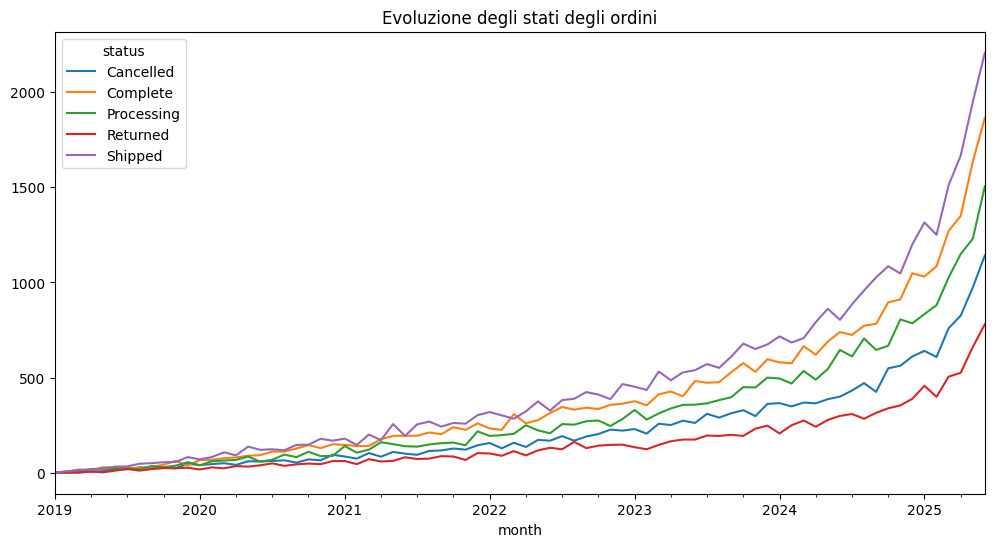

In [60]:
orders['month'] = orders['created_at'].dt.to_period('M')
monthly_status = orders.groupby(['month', 'status']).size().unstack(fill_value=0)
monthly_status.plot(kind='line', figsize=(12,6), title='Evoluzione degli stati degli ordini')


In [63]:
# Filtra prodotti non ancora venduti
unsold_inventory = inventory[inventory['sold_at'].isna()]

# Conta quante unità ci sono per ciascun product_id
inventory_status = unsold_inventory.groupby('product_id').size().reset_index(name='units_available')

# Ordina dal prodotto con più unità disponibili
inventory_status = inventory_status.sort_values(by='units_available', ascending=False)

# Mostra i top 10
inventory_status.head(10)


,product_id,units_available
22777,22844,35
27777,27850,35
16595,16659,33
28437,28510,33
22515,22582,33
19359,19425,32
18234,18299,32
20145,20211,32
27584,27656,32
23087,23154,32


In [64]:
# Unisci per avere dettagli descrittivi
inventory_detailed = inventory_status.merge(
    inventory[['product_id', 'product_name', 'product_brand', 'product_category']].drop_duplicates(),
    on='product_id',
    how='left'
)

# Visualizza
inventory_detailed.head(10)


,product_id,units_available,product_name,product_brand,product_category
0,22844,35,Calvin Klein Sportswear Men's Ripstop Cargo Short,Calvin Klein,Shorts
1,27850,35,Volcom Men's Gunshot Board Short,Volcom,Swim
2,16659,33,Woolrich Men's Elite Oxford CCW Concealed Carr...,Woolrich,Tops & Tees
3,28510,33,Carhartt Men's Winter Dex Kevlar Reinforced Sp...,Carhartt,Accessories
4,22582,33,Worn Men's Havasu Trouser,Worn Jeans,Pants
5,19425,32,Ed Hardy Mens Death or Glory Mock Neck Zip Up ...,Ed Hardy,Sweaters
6,18299,32,Adidas Men's Basketball 3-Stripe Pants,adidas,Active
7,20211,32,Allegra K Mens Korean Single Breasted Two Pock...,Allegra K,Suits & Sport Coats
8,27656,32,Quiksilver Men's Combat Drop Board Short,Quiksilver,Swim
9,23154,32,Rip Curl Men's Torque Cargo Short,Rip Curl,Shorts
